In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from warnings import filterwarnings
filterwarnings("ignore")

In [2]:
df = pd.read_csv(r'D:\Data Analytics\DA_python_projects\netflix_analysis\dataset\clean_dataset.csv' )
df.head(5)

,show_id,category,title,director,cast,country,date_added,rating,duration,genres,year_added,month_added,duration_value,duration_unit,duration_min,seasons,primary_country,primary_genre
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",2020,8,4,Seasons,NaN,4.0,Brazil,International TV Shows
1,s2,Movie,07:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,TV-MA,93 min,"Dramas, International Movies",2016,12,93,min,93.0,NaN,Mexico,Dramas
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,R,78 min,"Horror Movies, International Movies",2018,12,78,min,78.0,NaN,Singapore,Horror Movies
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...",2017,11,80,min,80.0,NaN,United States,Action & Adventure
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,PG-13,123 min,Dramas,2020,1,123,min,123.0,NaN,United States,Dramas


In [3]:
df.describe()

,year_added,month_added,duration_value,duration_min,seasons
count,7777.000000,7777.000000,7777.000000,5377.000000,2400.000000
mean,2018.493378,6.783850,69.204706,99.307978,1.760833
std,1.388144,3.591608,50.931983,28.530881,1.560603
min,2008.000000,1.000000,1.000000,3.000000,1.000000
25%,2018.000000,4.000000,2.000000,86.000000,1.000000
50%,2019.000000,7.000000,88.000000,98.000000,1.000000
75%,2020.000000,10.000000,106.000000,114.000000,2.000000
max,2021.000000,12.000000,312.000000,312.000000,16.000000


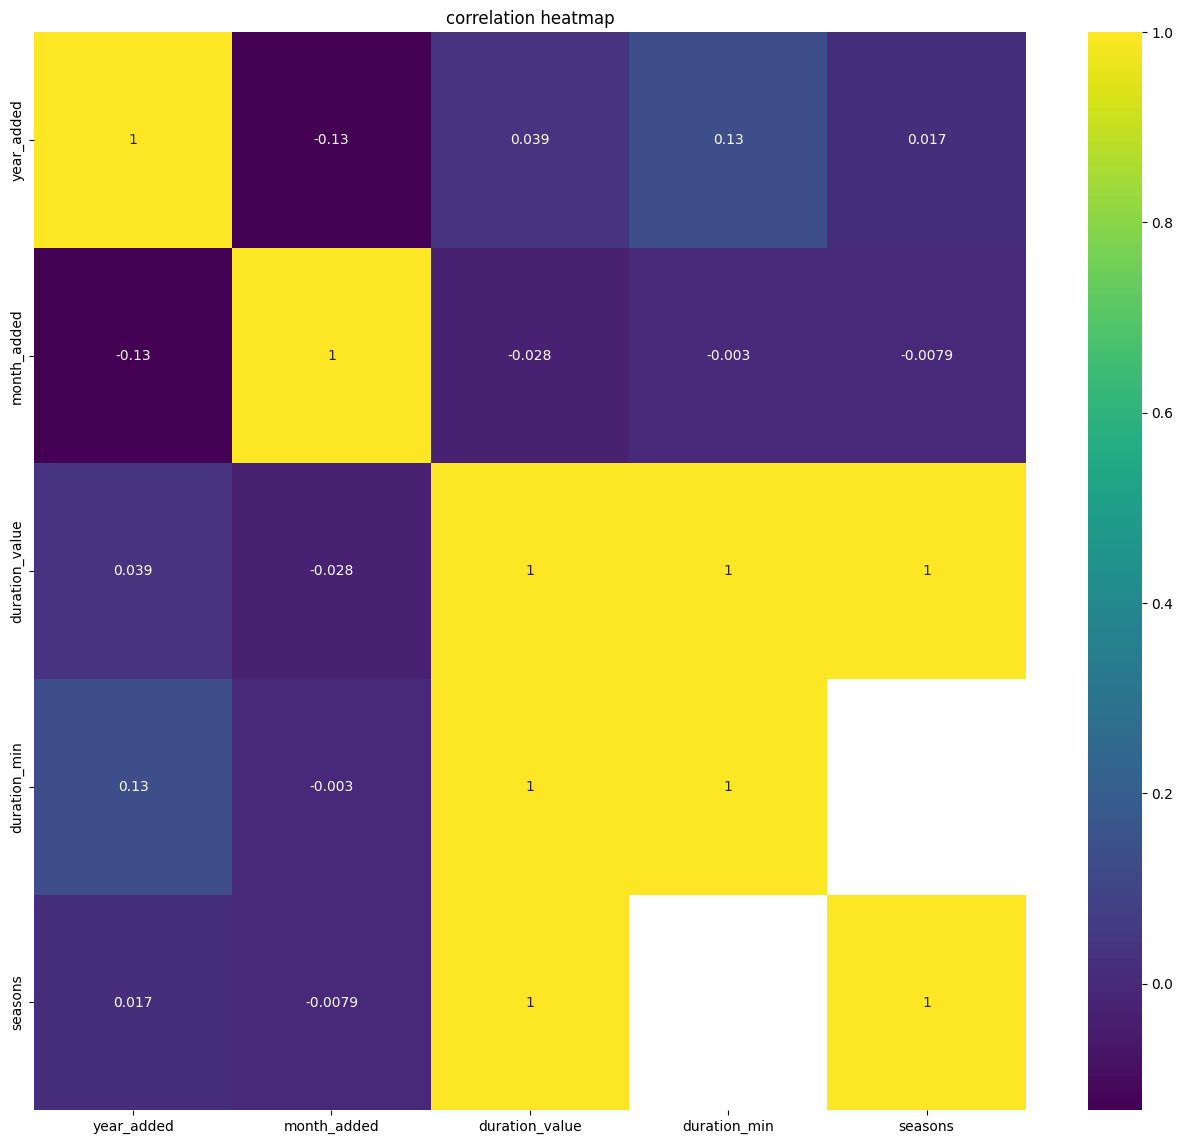

In [6]:
drop_col = df.drop(columns=['show_id'])
numeric_cols = drop_col.select_dtypes(include=['int64','float32','int32','float64'])
plt.figure(figsize=(16,14))
sns.heatmap(numeric_cols.corr() , annot=True ,cmap="viridis" )
plt.title("correlation heatmap")
plt.show()

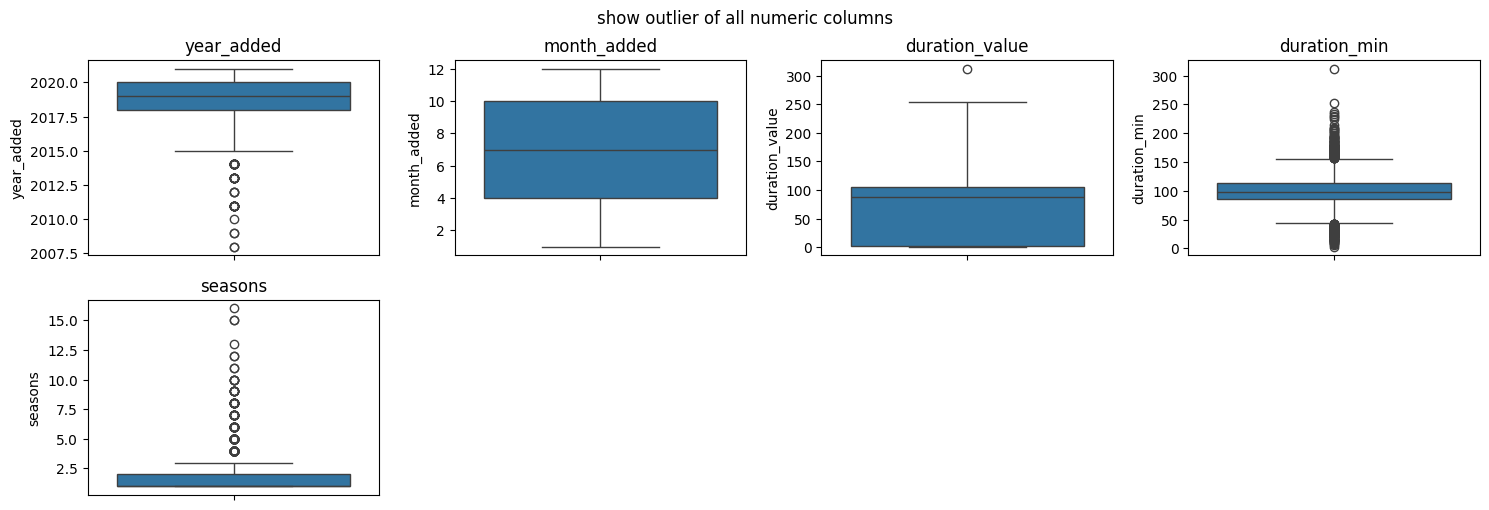

In [7]:
# numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 4, i + 1) # adjust the number of rows and columns as needed
    sns.boxplot(df[col])
    plt.title(col)
plt.suptitle('show outlier of all numeric columns')
plt.tight_layout()
plt.show()

In [9]:
# how many outlier in column??
def detect_outliers(df , col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_iqr = ((df[col] < lower_bound) | (df[col] > upper_bound))
    print(f"IQR method identified {outliers_iqr.sum()} outliers in {col}")
    return outliers_iqr

outlier_col = ['year_added' , 'month_added' , 'duration_value' , 'duration_min' , 'seasons']

for col in outlier_col:
    detect_outliers(df ,col)

IQR method identified 57 outliers in year_added
IQR method identified 0 outliers in month_added
IQR method identified 1 outliers in duration_value
IQR method identified 337 outliers in duration_min
IQR method identified 231 outliers in seasons


# 📊KPI

In [64]:
total_genere = df['primary_genre'].nunique()
print(f'total genere avalilable {total_genere}')

avg_duration = df['duration_min'].mean()
print(f'avg duration min {avg_duration.round(2)} min')

total_movies = (df["category"] == "Movie").sum()
print(f"Total Movies: {total_movies:,}")

total_tv_shows = (df["category"] == "TV Show").sum()
print(f"Total TV Shows: {total_tv_shows:,}")
df.shape

total genere avalilable 36
avg duration min 99.31 min
Total Movies: 5,377
Total TV Shows: 2,400


(7777, 18)

# 📊analysis

**What % of TV shows have just 1 season**

In [49]:
# Filter only TV Shows
tv_shows = df[df['category'] == 'TV Show']

# Total number of TV Shows
total_tv = len(tv_shows)

# Number of TV Shows with exactly 1 season
one_season = len(tv_shows[tv_shows['seasons'] == 1])

# Calculate percentage
percentage = (one_season / total_tv) * 100

# Display result
print(f"Total TV Shows          : {total_tv}")
print(f"TV Shows with 1 Season  : {one_season}")
print(f"Percentage              : {percentage:.2f}%")

Total TV Shows          : 2400
TV Shows with 1 Season  : 1608
Percentage              : 67.00%


**What does the movie duration distribution look like, and what is the typical length?**

Movie Duration Statistics:
-----------------------------------
Mean Duration     : 99.3 minutes
Median Duration   : 98.0 minutes
Mode Duration     : 90 minutes
Minimum Duration  : 3 minutes
Maximum Duration  : 312 minutes
Standard Deviation: 28.5 minutes


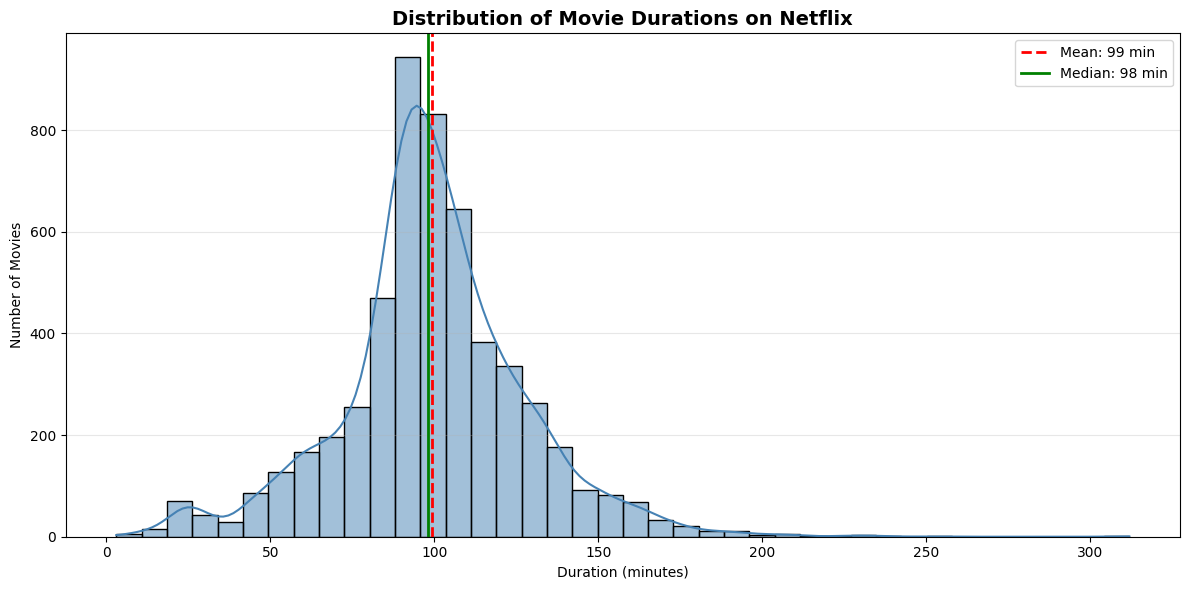

In [48]:
# Filter only Movies and remove missing durations
movies = df[df['category'] == 'Movie'].copy()
movie_durations = movies['duration_min']

# ==============================
# 1. Basic Statistics (Typical Length)
# ==============================
print("Movie Duration Statistics:")
print("-" * 35)
print(f"Mean Duration     : {movie_durations.mean():.1f} minutes")
print(f"Median Duration   : {movie_durations.median():.1f} minutes")
print(f"Mode Duration     : {movie_durations.mode().values[0]:.0f} minutes")
print(f"Minimum Duration  : {movie_durations.min():.0f} minutes")
print(f"Maximum Duration  : {movie_durations.max():.0f} minutes")
print(f"Standard Deviation: {movie_durations.std():.1f} minutes")

# ==============================
# 2. Distribution Visualization
# ==============================
plt.figure(figsize=(12, 6))

# Histogram + KDE
sns.histplot(movie_durations, bins=40, kde=True, color='steelblue', edgecolor='black')

plt.axvline(movie_durations.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {movie_durations.mean():.0f} min')
plt.axvline(movie_durations.median(), color='green', linestyle='-', linewidth=2, label=f'Median: {movie_durations.median():.0f} min')

plt.title('Distribution of Movie Durations on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**What is the rating distribution for Movies vs TV Shows?**

Rating Distribution (Movies vs TV Shows):



category,Movie,TV Show
rating,,
TV-MA,1845,1016
TV-14,1272,656
R,663,2
TV-PG,505,299
PG-13,386,0
PG,247,0
TV-Y,117,162
TV-G,111,83
TV-Y7,95,175


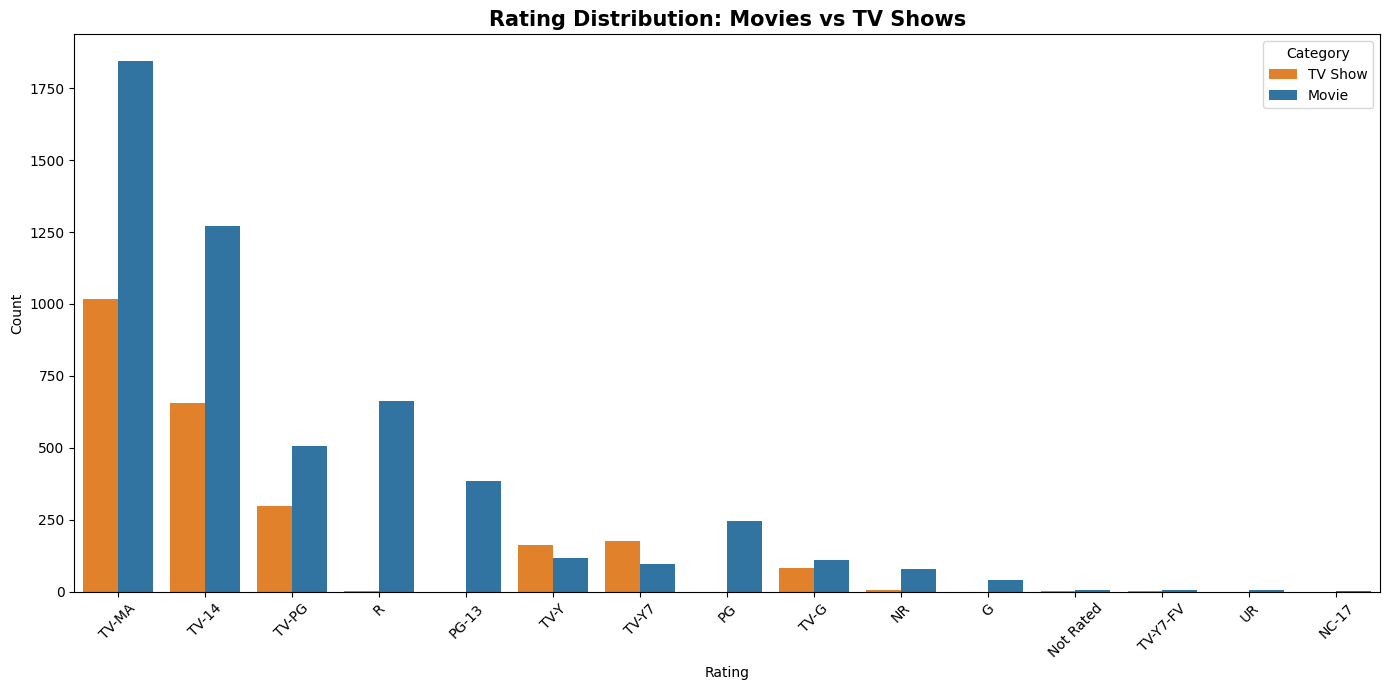

In [68]:
# Rating distribution for Movies vs TV Shows
rating_dist = (
    df.groupby(['category', 'rating'])
    .size()
    .unstack(fill_value=0)
    .T
    .sort_values(by='Movie', ascending=False)
)

print("Rating Distribution (Movies vs TV Shows):\n")
display(rating_dist)

plt.figure(figsize=(14, 7))

sns.countplot(
    data=df,
    x='rating',
    hue='category',
    order=df['rating'].value_counts().index,
    palette={'Movie': '#1f77b4', 'TV Show': '#ff7f0e'}
)

plt.title('Rating Distribution: Movies vs TV Shows', fontsize=15, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Category')
plt.tight_layout()
plt.show()

**top 10 director who make higest no of movie**

,Director,Number of Movies
0,Jan Suter,21
1,Raúl Campos,19
2,Marcus Raboy,15
3,Jay Karas,15
4,Cathy Garcia-Molina,13
5,Jay Chapman,12
6,Youssef Chahine,12
7,Martin Scorsese,12
8,Steven Spielberg,10
9,Shannon Hartman,9


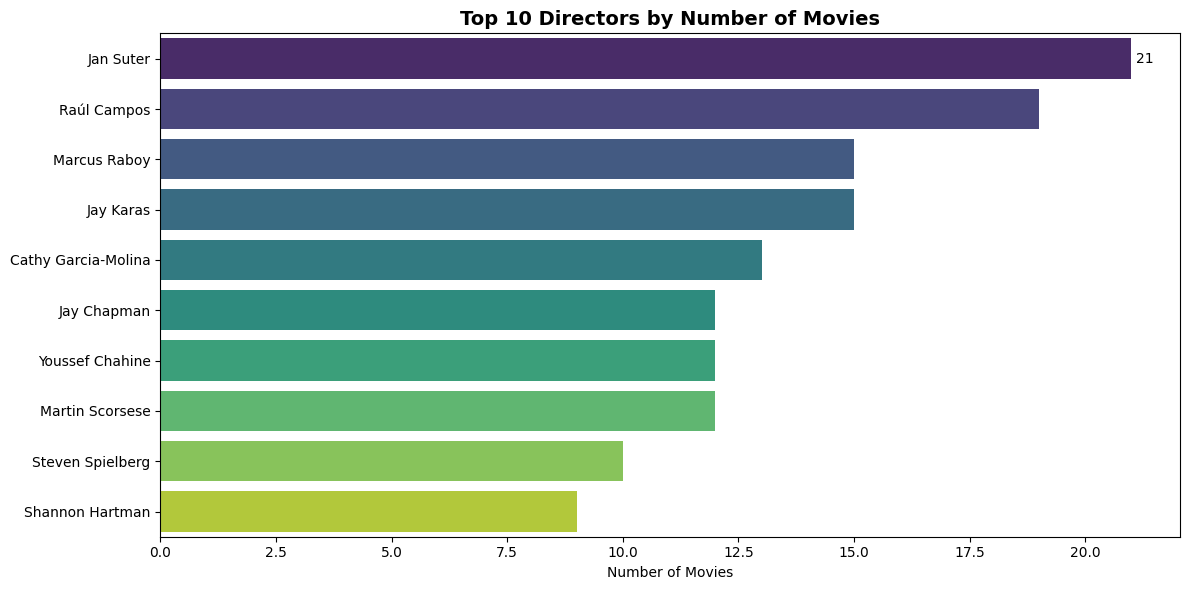

In [70]:
movies = df[df["category"] == "Movie"].copy()

movies_exploded = (
    movies.assign(director=movies["director"].str.split(","))
    .explode("director")
)
movies_exploded["director"] = movies_exploded["director"].str.strip()

top_10_directors = (
    movies_exploded.loc[movies_exploded["director"] != "Unknown", "director"]
    .value_counts()
    .head(10)
    .reset_index()
)
top_10_directors.columns = ["Director", "Number of Movies"]
display(top_10_directors)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top_10_directors, x="Number of Movies", y="Director",
                 hue="Director", palette="viridis", legend=False)
ax.bar_label(ax.containers[0], padding=3)   # shows count on each bar
plt.title("Top 10 Directors by Number of Movies", fontsize=14, fontweight="bold")
plt.xlabel("Number of Movies")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Which months does Netflix add the most content (seasonality)?**

Content Added by Month (Overall):


,Month Name,Total Content
0,January,757
1,February,472
2,March,669
3,April,601
4,May,543
5,June,542
6,July,600
7,August,618
8,September,619
9,October,785


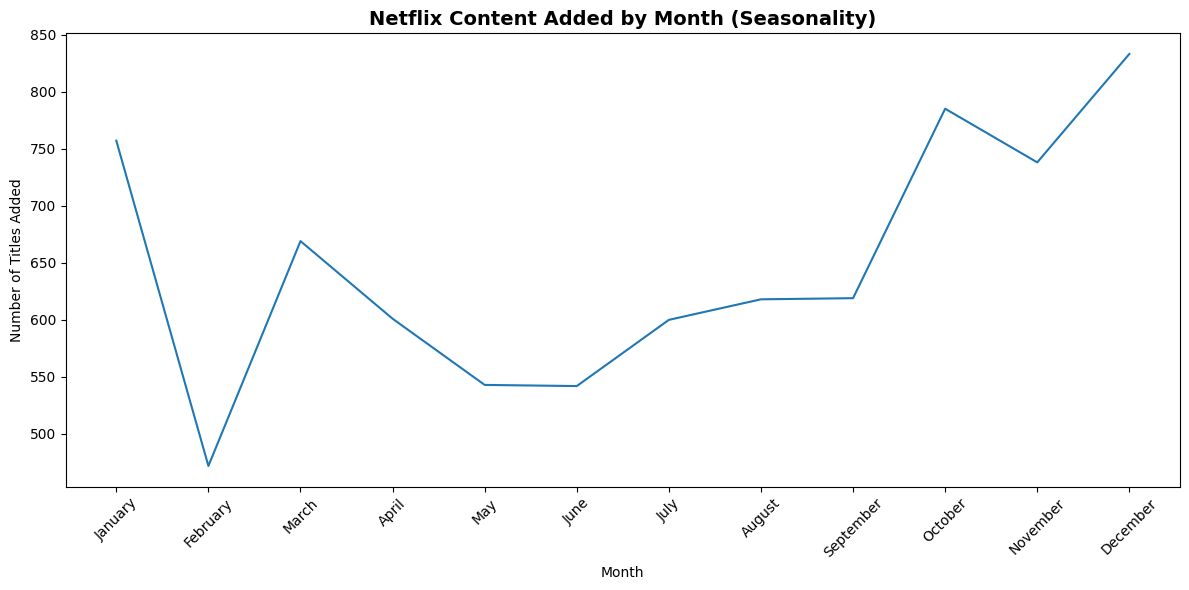

In [62]:
# Overall content added by Month
monthly_content = (
    df['month_added']
    .value_counts()
    .sort_index()
    .reset_index()
)
monthly_content.columns = ['Month', 'Total Content']

# Map month numbers to names
month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}
monthly_content['Month Name'] = monthly_content['Month'].map(month_names)

print("Content Added by Month (Overall):")
display(monthly_content[['Month Name', 'Total Content']])

# Visualization
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=monthly_content,
    x='Month Name',
    y='Total Content',
    palette='viridis'
)
plt.title('Netflix Content Added by Month (Seasonality)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Titles Added')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**content added per year IN NETFLIX**

Yearly Total Releases (Movies vs TV Shows):



category,Movie,TV Show
year_added,,
2008,1,1
2009,2,0
2010,1,0
2011,13,0
2012,3,0
2013,6,5
2014,19,6
2015,58,30
2016,258,185


<Figure size 1200x600 with 0 Axes>

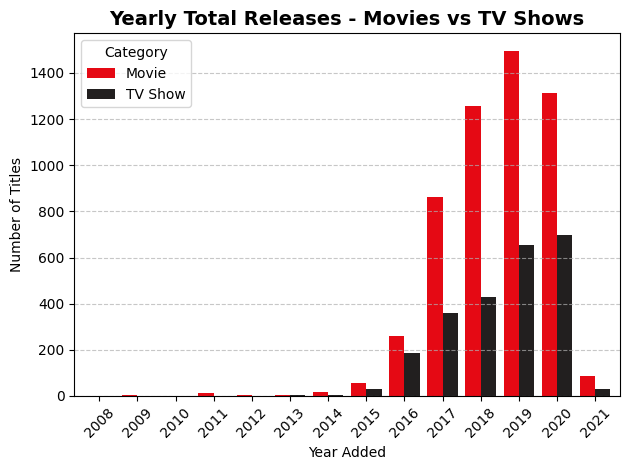

In [31]:
# Yearly count of Movies and TV Shows (separate)
yearly_counts = (
    df.groupby(["year_added", "category"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

print("Yearly Total Releases (Movies vs TV Shows):\n")
display(yearly_counts)

# Optional: Visualization
plt.figure(figsize=(12, 6))
yearly_counts.plot(kind="bar", width=0.8, color=["#E50914", "#221F1F"])
plt.title("Yearly Total Releases - Movies vs TV Shows", fontsize=14, fontweight="bold")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.legend(title="Category")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

**country wise realese movie**

Country-wise Movie Releases:

             Country  Number of Movies
       United States              2100
               India               883
      United Kingdom               341
              Canada               175
              France               137
               Spain               119
               Egypt                93
              Mexico                79
              Turkey                78
               Japan                75
           Indonesia                74
           Hong Kong                74
         Philippines                74
             Germany                68
             Nigeria                63
           Australia                56
              Brazil                52
           Argentina                50
               China                48
               Italy                42
         South Korea                42
            Thailand                39
        South Africa                30
         Netherlands              

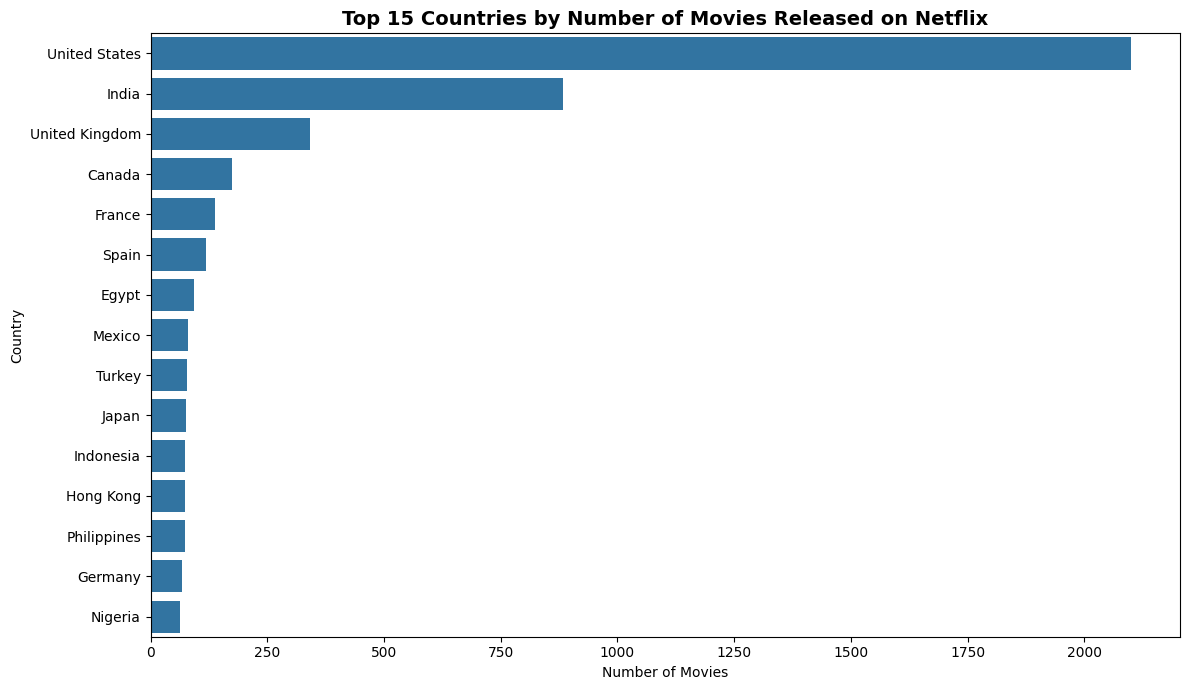

In [ ]:
# Filter only Movies
movies = df[df['category'] == 'Movie']

# Country-wise count of Movies
country_movie_count = (
    movies[movies['primary_country'] != 'Unknown']['primary_country']
    .value_counts()
    .reset_index()
).head(15)
country_movie_count.columns = ['Country', 'Number of Movies']

# Display the result
print("Country-wise Movie Releases:\n")
print(country_movie_count.to_string(index=False))

# # Optional: Top 15 countries bar plot
plt.figure(figsize=(12, 7))
sns.barplot(
    data=country_movie_count.head(15),
    x='Number of Movies',
    y='Country'
)
plt.title('Top 15 Countries by Number of Movies Released on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Number of Movies')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [71]:
movies = df[df['category'] == 'Movie'].copy()

movies_exploded = (
    movies.assign(country=movies['country'].str.split(','))
    .explode('country')
)
movies_exploded['country'] = movies_exploded['country'].str.strip()
movies_exploded = movies_exploded[~movies_exploded['country'].isin(['Unknown', ''])]

country_movie_count = (
    movies_exploded['country'].value_counts().reset_index()
)
country_movie_count.columns = ['Country', 'Number of Movies']
country_movie_count['Share %'] = (
    country_movie_count['Number of Movies'] / len(movies) * 100
).round(1)

print(country_movie_count.head(15).to_string(index=False))

       Country  Number of Movies  Share %
 United States              2431     45.2
         India               915     17.0
United Kingdom               467      8.7
        Canada               286      5.3
        France               265      4.9
         Spain               158      2.9
       Germany               157      2.9
         Japan               103      1.9
         China               102      1.9
        Mexico               101      1.9
     Hong Kong                97      1.8
         Egypt                97      1.8
     Australia                84      1.6
        Turkey                80      1.5
   Philippines                77      1.4


**country wise release tv show**

Country-wise Movie Releases:

             Country  Number of Movies
       United States               777
      United Kingdom               235
               Japan               161
         South Korea               152
              Canada                84
               India                73
              Taiwan                70
              France                59
           Australia                51
               Spain                49
              Mexico                44
               China                38
              Turkey                28
              Brazil                27
             Germany                24
            Colombia                23
            Thailand                22
           Singapore                18
           Argentina                18
               Italy                17
              Russia                15
               Egypt                12
             Denmark                11
              Norway              

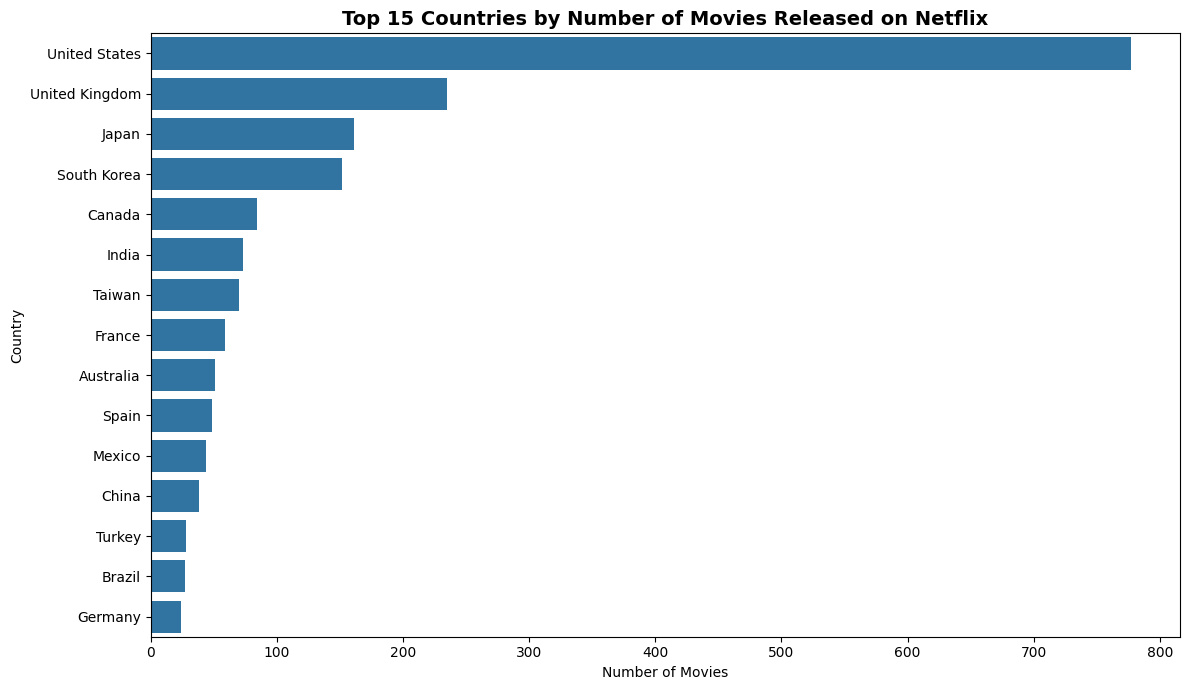

In [55]:
# Filter only Movies
movies = df[df['category'] == 'TV Show']

# Country-wise count of Movies
country_movie_count = (
    movies[movies['primary_country'] != 'Unknown']['primary_country']
    .value_counts()
    .reset_index()
)
country_movie_count.columns = ['Country', 'Number of Movies']

# Display the result
print("Country-wise Movie Releases:\n")
print(country_movie_count.to_string(index=False))

# # Optional: Top 15 countries bar plot
plt.figure(figsize=(12, 7))
sns.barplot(
    data=country_movie_count.head(15),
    x='Number of Movies',
    y='Country'
)
plt.title('Top 15 Countries by Number of Movies Released on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Number of Movies')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

**top 10 primary_genre that have higest no of tv show and movies**

Top 10 Primary Genres by Number of Movies:


,Primary Genre,Number of Movies
0,Dramas,1384
1,Comedies,1074
2,Documentaries,751
3,Action & Adventure,721
4,Children & Family Movies,502
5,Stand-Up Comedy,321
6,Horror Movies,244
7,International Movies,114
8,Classic Movies,77
9,Movies,56



Top 10 Primary Genres by Number of TV Shows:


,Primary Genre,Number of TV Shows
0,International TV Shows,689
1,Crime TV Shows,369
2,Kids' TV,357
3,British TV Shows,231
4,Docuseries,193
5,Anime Series,147
6,TV Comedies,109
7,Reality TV,102
8,TV Dramas,62
9,TV Action & Adventure,36


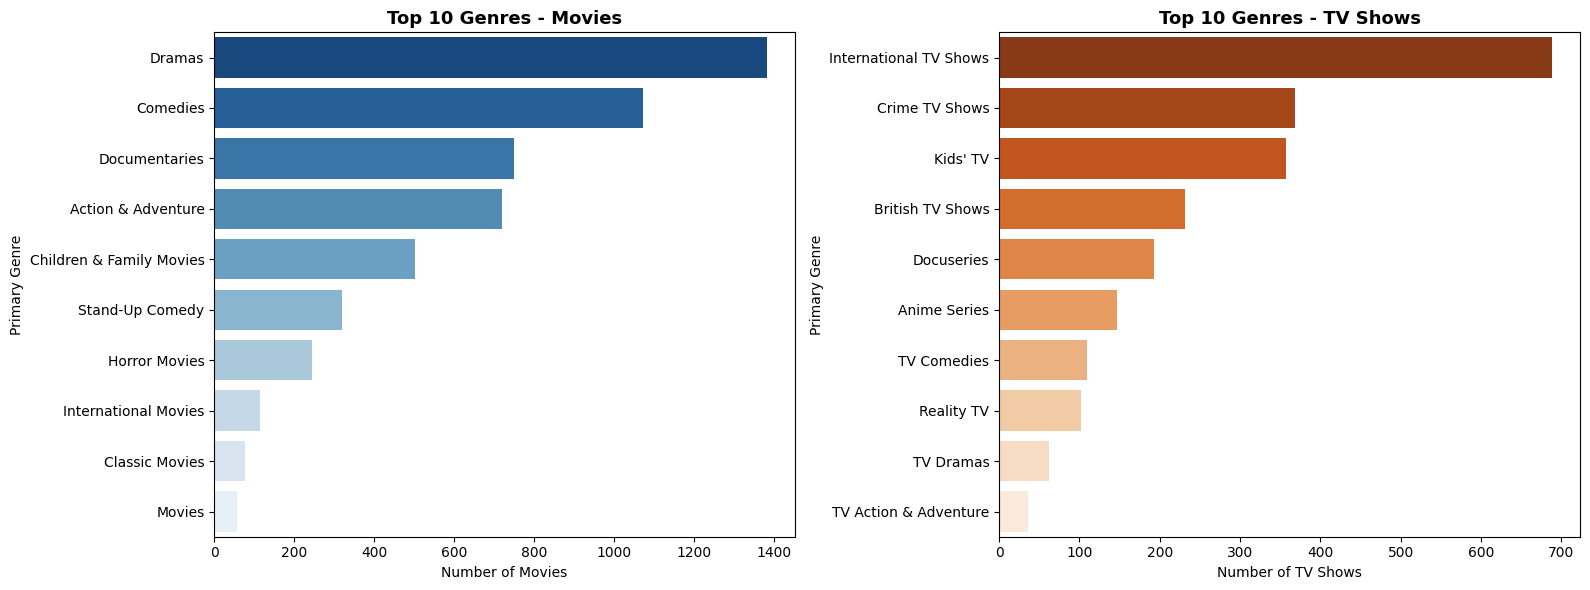

In [46]:
# ==============================
# Top 10 Primary Genres - Movies
# ==============================
top_10_movie_genres = (
    df[df['category'] == 'Movie']['primary_genre']
    .value_counts()
    .head(10)
    .reset_index()
)
top_10_movie_genres.columns = ['Primary Genre', 'Number of Movies']

print("Top 10 Primary Genres by Number of Movies:")
display(top_10_movie_genres)

# ==============================
# Top 10 Primary Genres - TV Shows
# ==============================
top_10_tv_genres = (
    df[df['category'] == 'TV Show']['primary_genre']
    .value_counts()
    .head(10)
    .reset_index()
)
top_10_tv_genres.columns = ['Primary Genre', 'Number of TV Shows']

print("\nTop 10 Primary Genres by Number of TV Shows:")
display(top_10_tv_genres)

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Movies
sns.barplot(data=top_10_movie_genres, x='Number of Movies', y='Primary Genre', 
            palette='Blues_r', ax=axes[0])
axes[0].set_title('Top 10 Genres - Movies', fontsize=13, fontweight='bold')

# TV Shows
sns.barplot(data=top_10_tv_genres, x='Number of TV Shows', y='Primary Genre', 
            palette='Oranges_r', ax=axes[1])
axes[1].set_title('Top 10 Genres - TV Shows', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

**Who are the top 10 most frequent actors**

,Actor,Number of Appearances
0,Anupam Kher,42
1,Shah Rukh Khan,35
2,Naseeruddin Shah,30
3,Om Puri,30
4,Takahiro Sakurai,29
5,Akshay Kumar,29
6,Boman Irani,27
7,Paresh Rawal,27
8,Yuki Kaji,27
9,Amitabh Bachchan,27


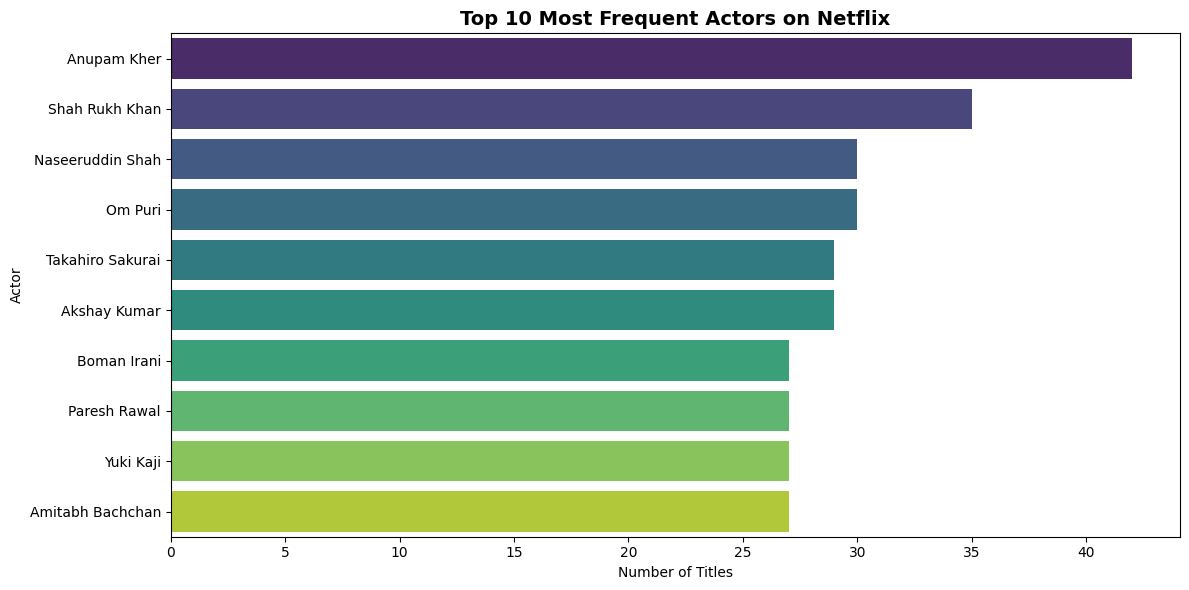

In [60]:
# Split the cast column and explode it
actors = (
    df[df['cast'] != 'Unknown']['cast']
    .str.split(', ')                   # split by comma + space
    .explode()                         # one actor per row
)

# Count frequency of each actor
top_10_actors = (
    actors
    .value_counts()
    .head(10)
    .reset_index()
)
top_10_actors.columns = ['Actor', 'Number of Appearances']

# Display the result
display(top_10_actors)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_10_actors,
    x='Number of Appearances',
    y='Actor',
    palette='viridis'
)
plt.title('Top 10 Most Frequent Actors on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Actor')
plt.tight_layout()
plt.show()